# Predicting NBA Player Positions with a PyTorch MLP

Predict a player's position (C, PF, PG, SF, SG) from 2016-17 season stats. The dataset is small (239 players), so the focus is clean preprocessing, a stratified train/val/test split, and early stopping.

In [1]:
%pip install -q datasets torch scikit-learn pandas numpy matplotlib


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

from datasets import load_dataset

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


In [3]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)


## Data

In [4]:
ds = load_dataset("noahgift/nba")
df = ds["train"].to_pandas()

print("Shape:", df.shape)
df.head()


Shape: (239, 42)


,Unnamed: 0,Rk,PLAYER,POSITION,AGE,MP,FG,FGA,FG%,3P,...,DRPM,RPM,WINS_RPM,PIE,PACE,W,SALARY_MILLIONS,PAGEVIEWS,TWITTER_FAVORITE_COUNT,TWITTER_RETWEET_COUNT
0,0,1,Russell Westbrook,PG,28,34.6,10.2,24.0,0.425,2.5,...,-0.47,6.27,17.34,23.0,102.31,46,26.50,4279.0,2130.5,559.0
1,1,2,James Harden,PG,27,36.4,8.3,18.9,0.440,3.2,...,-1.57,4.81,15.54,19.0,102.98,54,26.50,3279.0,969.0,321.5
2,2,4,Anthony Davis,C,23,36.1,10.3,20.3,0.505,0.5,...,3.90,4.35,12.81,19.2,100.19,31,22.12,82.5,368.0,104.0
3,3,6,DeMarcus Cousins,C,26,34.2,9.0,19.9,0.452,1.8,...,0.64,4.20,11.26,17.8,97.11,30,16.96,1625.5,102.0,91.5
4,4,7,Damian Lillard,PG,26,35.9,8.8,19.8,0.444,2.9,...,-1.49,3.14,10.72,15.9,99.68,38,24.33,1830.5,186.5,43.0


In [5]:
target_col = "POSITION"

# Drop ID-like columns (keep TEAM because it can help)
drop_cols = ["Unnamed: 0", "PLAYER"]
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

# Remove rows with missing target
df = df.dropna(subset=[target_col]).reset_index(drop=True)

print(df[target_col].value_counts())


POSITION
PF    52
PG    50
SG    48
SF    46
C     43
Name: count, dtype: int64


In [6]:
X = df.drop(columns=[target_col])
y = df[target_col].astype(str)

X.head(), y.head()


(   Rk  AGE    MP    FG   FGA    FG%   3P  3PA    3P%   2P  ...  DRPM   RPM  \
 0   1   28  34.6  10.2  24.0  0.425  2.5  7.2  0.343  7.7  ... -0.47  6.27   
 1   2   27  36.4   8.3  18.9  0.440  3.2  9.3  0.347  5.1  ... -1.57  4.81   
 2   4   23  36.1  10.3  20.3  0.505  0.5  1.8  0.299  9.7  ...  3.90  4.35   
 3   6   26  34.2   9.0  19.9  0.452  1.8  5.0  0.361  7.2  ...  0.64  4.20   
 4   7   26  35.9   8.8  19.8  0.444  2.9  7.7  0.370  6.0  ... -1.49  3.14   
 
    WINS_RPM   PIE    PACE   W  SALARY_MILLIONS  PAGEVIEWS  \
 0     17.34  23.0  102.31  46            26.50     4279.0   
 1     15.54  19.0  102.98  54            26.50     3279.0   
 2     12.81  19.2  100.19  31            22.12       82.5   
 3     11.26  17.8   97.11  30            16.96     1625.5   
 4     10.72  15.9   99.68  38            24.33     1830.5   
 
    TWITTER_FAVORITE_COUNT  TWITTER_RETWEET_COUNT  
 0                  2130.5                  559.0  
 1                   969.0                  32

## Stratified train / validation / test split

In [7]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)


Train: (167, 39) Val: (36, 39) Test: (36, 39)


## Preprocessing

In [8]:
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = [c for c in X.columns if c not in numeric_cols]

print("Numeric:", numeric_cols)
print("Categorical:", categorical_cols)


Numeric: ['Rk', 'AGE', 'MP', 'FG', 'FGA', 'FG%', '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%', 'FT', 'FTA', 'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'POINTS', 'GP', 'MPG', 'ORPM', 'DRPM', 'RPM', 'WINS_RPM', 'PIE', 'PACE', 'W', 'SALARY_MILLIONS', 'PAGEVIEWS', 'TWITTER_FAVORITE_COUNT', 'TWITTER_RETWEET_COUNT']
Categorical: ['TEAM']


In [9]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ],
    remainder="drop"
)

X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc   = preprocessor.transform(X_val)
X_test_proc  = preprocessor.transform(X_test)

# Convert to dense arrays (small dataset)
X_train_dense = X_train_proc.toarray() if hasattr(X_train_proc, "toarray") else np.asarray(X_train_proc)
X_val_dense   = X_val_proc.toarray()   if hasattr(X_val_proc, "toarray") else np.asarray(X_val_proc)
X_test_dense  = X_test_proc.toarray()  if hasattr(X_test_proc, "toarray") else np.asarray(X_test_proc)

print("Shapes:", X_train_dense.shape, X_val_dense.shape, X_test_dense.shape)
print("NaNs in train?", np.isnan(X_train_dense).any())


Shapes: (167, 80) (36, 80) (36, 80)
NaNs in train? False


In [10]:
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_val_enc   = label_encoder.transform(y_val)
y_test_enc  = label_encoder.transform(y_test)

class_names = label_encoder.classes_.tolist()
num_classes = len(class_names)

print("Classes:", class_names)


Classes: ['C', 'PF', 'PG', 'SF', 'SG']


In [11]:
X_train_t = torch.tensor(X_train_dense, dtype=torch.float32)
X_val_t   = torch.tensor(X_val_dense, dtype=torch.float32)
X_test_t  = torch.tensor(X_test_dense, dtype=torch.float32)

y_train_t = torch.tensor(y_train_enc, dtype=torch.long)
y_val_t   = torch.tensor(y_val_enc, dtype=torch.long)
y_test_t  = torch.tensor(y_test_enc, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=16, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=16, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=16, shuffle=False)

X_train_t.shape


torch.Size([167, 80])

## Model

In [12]:
class NBAClassifier(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        return self.net(x)

input_dim = X_train_t.shape[1]
model = NBAClassifier(input_dim, num_classes)
model


NBAClassifier(
  (net): Sequential(
    (0): Linear(in_features=80, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.25, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=5, bias=True)
  )
)

## Training with early stopping

In [13]:
device = torch.device("cpu")  # fine for this dataset
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

def batch_accuracy(logits, y_true):
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()

epochs = 100
best_val_loss = float("inf")
best_state = None
patience = 10
patience_counter = 0

for epoch in range(1, epochs + 1):
    # ---- train ----
    model.train()
    train_losses, train_accs = [], []

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())
        train_accs.append(batch_accuracy(logits, yb))

    # ---- val ----
    model.eval()
    val_losses, val_accs = [], []

    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)

            val_losses.append(loss.item())
            val_accs.append(batch_accuracy(logits, yb))

    tr_loss = float(np.mean(train_losses))
    tr_acc  = float(np.mean(train_accs))
    va_loss = float(np.mean(val_losses))
    va_acc  = float(np.mean(val_accs))

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(va_loss)
    history["val_acc"].append(va_acc)

    print(f"Epoch {epoch:03d}/{epochs} | "
          f"train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} | "
          f"val_loss={va_loss:.4f} val_acc={va_acc:.4f}")

    # Early stopping
    if va_loss < best_val_loss - 1e-5:
        best_val_loss = va_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

# Restore best weights
if best_state is not None:
    model.load_state_dict(best_state)


Epoch 001/100 | train_loss=1.5947 train_acc=0.2532 | val_loss=1.5833 val_acc=0.1875
Epoch 002/100 | train_loss=1.5126 train_acc=0.4367 | val_loss=1.5312 val_acc=0.2292
Epoch 003/100 | train_loss=1.4282 train_acc=0.4968 | val_loss=1.4393 val_acc=0.2292
Epoch 004/100 | train_loss=1.3435 train_acc=0.4619 | val_loss=1.3502 val_acc=0.3333
Epoch 005/100 | train_loss=1.2143 train_acc=0.5593 | val_loss=1.2852 val_acc=0.3958
Epoch 006/100 | train_loss=1.1090 train_acc=0.6088 | val_loss=1.2272 val_acc=0.3750
Epoch 007/100 | train_loss=1.0085 train_acc=0.6445 | val_loss=1.1995 val_acc=0.3750
Epoch 008/100 | train_loss=0.9495 train_acc=0.6291 | val_loss=1.1471 val_acc=0.5000
Epoch 009/100 | train_loss=0.8996 train_acc=0.6591 | val_loss=1.1089 val_acc=0.5000
Epoch 010/100 | train_loss=0.8681 train_acc=0.6599 | val_loss=1.0704 val_acc=0.4792
Epoch 011/100 | train_loss=0.8082 train_acc=0.7297 | val_loss=1.0177 val_acc=0.4792
Epoch 012/100 | train_loss=0.7656 train_acc=0.7622 | val_loss=1.0313 val_acc

## Learning curves

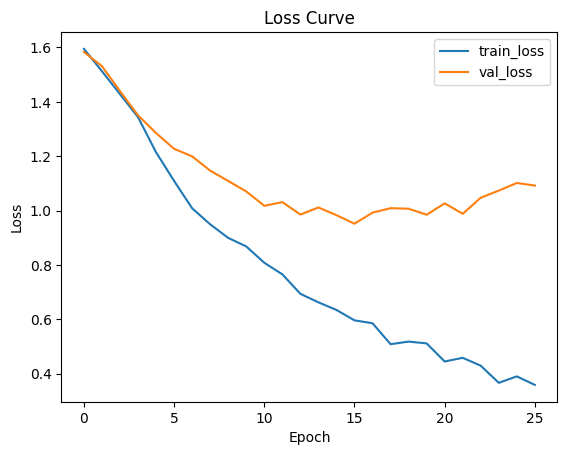

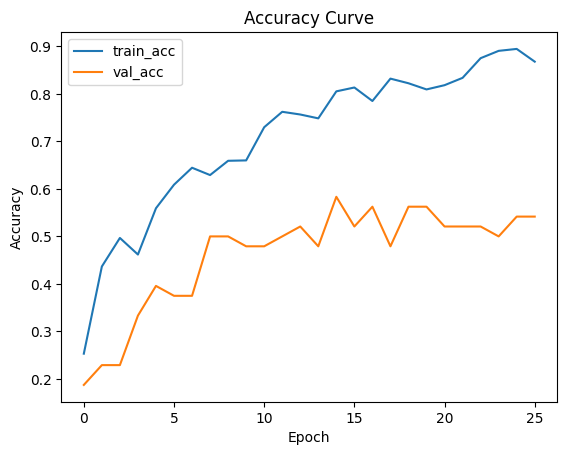

In [14]:
plt.figure()
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.show()

plt.figure()
plt.plot(history["train_acc"], label="train_acc")
plt.plot(history["val_acc"], label="val_acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()
plt.show()


## Test set evaluation

In [15]:
model.eval()
all_logits = []
all_true = []

with torch.no_grad():
    for xb, yb in test_loader:
        logits = model(xb.to(device)).cpu()
        all_logits.append(logits)
        all_true.append(yb)

all_logits = torch.cat(all_logits, dim=0)
all_true = torch.cat(all_true, dim=0)

y_pred = torch.argmax(all_logits, dim=1).numpy()
y_true = all_true.numpy()


In [16]:
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))


              precision    recall  f1-score   support

           C     0.6000    0.4286    0.5000         7
          PF     0.4000    0.5000    0.4444         8
          PG     0.8750    1.0000    0.9333         7
          SF     0.6667    0.5714    0.6154         7
          SG     0.7143    0.7143    0.7143         7

    accuracy                         0.6389        36
   macro avg     0.6512    0.6429    0.6415        36
weighted avg     0.6442    0.6389    0.6360        36



<Figure size 640x480 with 0 Axes>

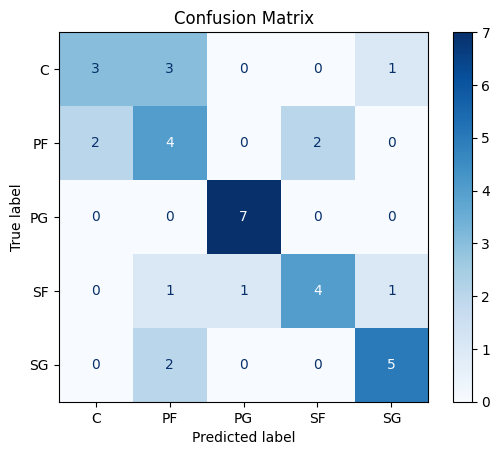

In [17]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

plt.figure()
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()
